In [1]:
# Celda 1 — Setup P3
!pip install -q ultralytics roboflow

import torch
from ultralytics import YOLO
import os, json

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# Verificar ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 43.2/235.7 GB disk)


In [2]:
# Celda 2 — Descargar dataset PPE via Roboflow
from roboflow import Roboflow
import os

API_KEY = "7kmgqGaQwL0DbFzzi4fq"  # <-- reemplaza con tu key

rf = Roboflow(api_key=API_KEY)
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
version = project.version(7)
dataset = version.download("yolov8", location="/content/ppe_data")

print("\nEstructura del dataset:")
for root, dirs, files in os.walk("/content/ppe_data"):
    level = root.replace("/content/ppe_data", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 1:
        print(f"{'  '*(level+1)}-> {len(files)} archivos")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/ppe_data in yolov8:: 100%|██████████| 3264/3264 [00:00<00:00, 7897.20it/s]


Estructura del dataset:
ppe_data/
  valid/
    -> 0 archivos
    labels/
    images/
  test/
    -> 0 archivos
    labels/
    images/
  train/
    -> 0 archivos
    labels/
    images/


In [3]:
import subprocess
result = subprocess.run(
    ['find', '/content/ppe_data', '-name', '*.jpg', '-maxdepth', '5'],
    capture_output=True, text=True
)
print(result.stdout[:2000] if result.stdout else "Sin .jpg")

result2 = subprocess.run(
    ['find', '/content/ppe_data', '-maxdepth', '4', '-type', 'd'],
    capture_output=True, text=True
)
print("\nCarpetas encontradas:")
print(result2.stdout)

/content/ppe_data/valid/images/001753_jpg.rf.e8b51a31c238b5c9f646bde8b0ed1116.jpg
/content/ppe_data/valid/images/ppe_1228_jpg.rf.44a4b6d24d3c79b07db628fd94c88174.jpg
/content/ppe_data/valid/images/006197_jpg.rf.9aeb510e18f0e604e6114d69714f26d9.jpg
/content/ppe_data/valid/images/ppe_0355_jpg.rf.943433bc0bdf4b1e308788246b965501.jpg
/content/ppe_data/valid/images/front_crawling_00076_jpg.rf.cae763db451792c8fb35e65549506884.jpg
/content/ppe_data/valid/images/Mask-detector1_mov-46_jpg.rf.655e5443852fc9bb0a4e4c11db56465f.jpg
/content/ppe_data/valid/images/construction-1037-_jpg.rf.dbe4885d4f972a7c6e60d5c37d4ac325.jpg
/content/ppe_data/valid/images/-4906-_png_jpg.rf.72ded976355642af176b34e064c0e271.jpg
/content/ppe_data/valid/images/construction-1-_mp4-147_jpg.rf.c6cd2773f9b057291d20ae25392b7871.jpg
/content/ppe_data/valid/images/construction-711-_jpg.rf.17b063601f9261d83c6835479bc14309.jpg
/content/ppe_data/valid/images/construction-4-_mp4-20_jpg.rf.ad1993827ddd2d227a60725244bdd4fb.jpg
/cont

In [4]:
# Celda 3 — Explorar dataset y clases
import os, yaml

base = "/content/ppe_data"

# Contar imágenes
for split in ['train', 'valid', 'test']:
    imgs = os.listdir(f'{base}/{split}/images')
    lbls = os.listdir(f'{base}/{split}/labels')
    print(f"{split}: {len(imgs)} imágenes, {len(lbls)} labels")

# Ver clases
with open(f'{base}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

print(f"\nClases ({data['nc']}):")
for i, name in enumerate(data['names']):
    print(f"  {i}: {name}")

train: 1535 imágenes, 1535 labels
valid: 57 imágenes, 57 labels
test: 34 imágenes, 34 labels

Clases (9):
  0: Gloves
  1: Hardhat
  2: Mask
  3: NO-Hardhat
  4: NO-Mask
  5: NO-Safety Vest
  6: Person
  7: Safety Shoes
  8: Safety Vest


In [5]:
# Celda 4 — Entrenar YOLOv8
from ultralytics import YOLO
import yaml, os

# Verificar y corregir rutas en data.yaml
with open('/content/ppe_data/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

# Actualizar rutas absolutas
data['train'] = '/content/ppe_data/train/images'
data['val']   = '/content/ppe_data/valid/images'
data['test']  = '/content/ppe_data/test/images'

with open('/content/ppe_data/data.yaml', 'w') as f:
    yaml.dump(data, f)

print("data.yaml actualizado")
print(yaml.dump(data))

# Entrenar YOLOv8m (medium — balance rendimiento/velocidad)
model = YOLO('yolov8m.pt')  # descarga pesos preentrenados COCO

results = model.train(
    data    = '/content/ppe_data/data.yaml',
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    device  = 'cuda',
    project = '/content/yolo_runs',
    name    = 'ppe_v1',
    patience= 10,          # early stopping
    mosaic  = 1.0,         # augmentation mosaico
    degrees = 10,          # rotación
    fliplr  = 0.5,
    hsv_h   = 0.015,
    hsv_s   = 0.7,
    hsv_v   = 0.4,
    save    = True,
    verbose = False
)

print("\nEntrenamiento completo.")
print(f"Best mAP@0.5: {results.results_dict.get('metrics/mAP50(B)', 'N/A'):.4f}")
print(f"Best mAP@0.5:0.95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A'):.4f}")

data.yaml actualizado
names:
- Gloves
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Shoes
- Safety Vest
nc: 9
roboflow:
  license: CC BY 4.0
  project: construction-site-safety
  url: https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety/dataset/7
  version: 7
  workspace: roboflow-universe-projects
test: /content/ppe_data/test/images
train: /content/ppe_data/train/images
val: /content/ppe_data/valid/images

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_data/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Model summary (fused): 93 layers, 25,844,971 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1478.5±359.0 MB/s, size: 53.9 KB)
val: Scanning /content/ppe_data/test/labels... 34 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 34/34 1.5Kit/s 0.0s
val: New cache created: /content/ppe_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.0it/s 1.0s
                   all         34         52        0.9      0.899      0.967      0.433
Speed: 4.5ms preprocess, 14.8ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val
=== Evaluación por Clase — Test Set ===
Clase                    P       R    mAP50   mAP50-95
-------------------------------------------------------
Gloves               1.000   0.627    0.995      0.211
Hardhat              0

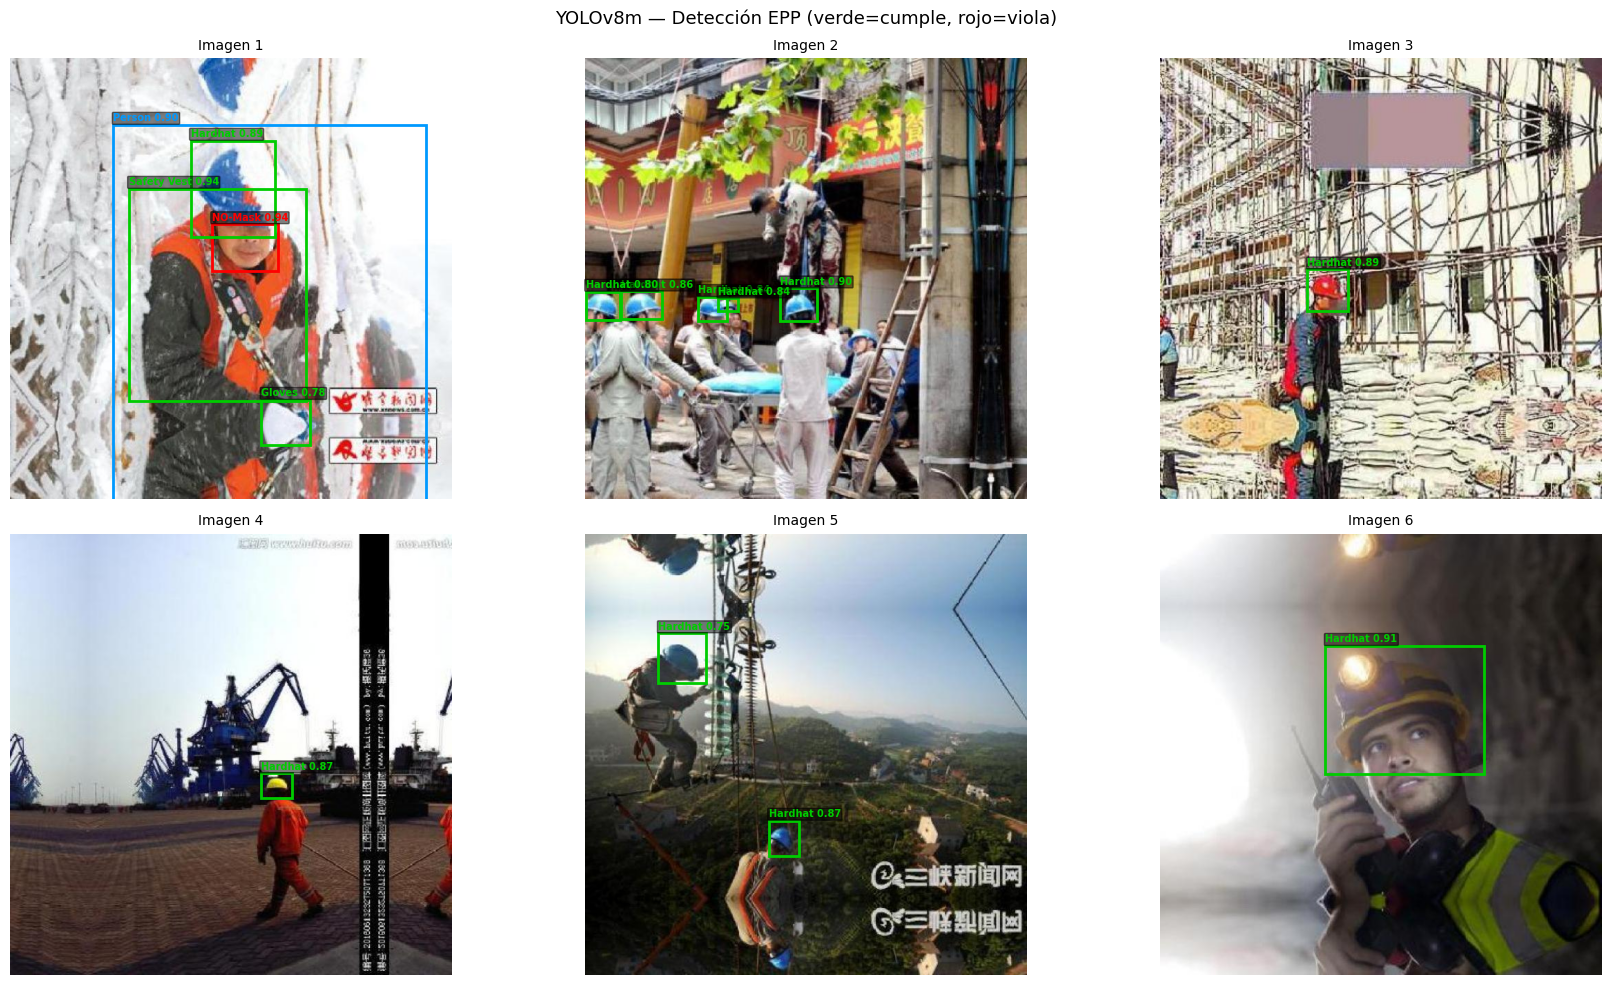

Visualización guardada.


In [6]:
# Celda 5 — Evaluación por clase + visualizaciones
from ultralytics import YOLO
import matplotlib.pyplot as plt, matplotlib.patches as patches
import numpy as np, os
from PIL import Image

# Cargar mejor modelo
model = YOLO('/content/yolo_runs/ppe_v1/weights/best.pt')

# Evaluación completa en test set
metrics = model.val(data='/content/ppe_data/data.yaml',
                    split='test', verbose=False)

# Métricas por clase
class_names = ['Gloves','Hardhat','Mask','NO-Hardhat',
                'NO-Mask','NO-Safety Vest','Person','Safety Shoes','Safety Vest']

print("=== Evaluación por Clase — Test Set ===")
print(f"{'Clase':<18} {'P':>7} {'R':>7} {'mAP50':>8} {'mAP50-95':>10}")
print("-"*55)

maps50    = metrics.box.ap50
maps5095  = metrics.box.ap
prec      = metrics.box.p
rec       = metrics.box.r

for i, name in enumerate(class_names):
    if i < len(maps50):
        print(f"{name:<18} {prec[i]:>7.3f} {rec[i]:>7.3f} {maps50[i]:>8.3f} {maps5095[i]:>10.3f}")

print(f"\n{'ALL':<18} {metrics.box.mp:>7.3f} {metrics.box.mr:>7.3f} "
      f"{metrics.box.map50:>8.3f} {metrics.box.map:>10.3f}")

# Visualizar predicciones en test set
test_imgs = sorted(os.listdir('/content/ppe_data/test/images'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

COLORS = {'Hardhat':'#00CC00', 'Safety Vest':'#00CC00', 'Gloves':'#00CC00',
          'Mask':'#00CC00', 'Safety Shoes':'#00CC00',
          'NO-Hardhat':'#FF0000', 'NO-Safety Vest':'#FF0000',
          'NO-Mask':'#FF0000', 'Person':'#0099FF'}

for i, img_f in enumerate(test_imgs):
    img_path = f'/content/ppe_data/test/images/{img_f}'
    results = model(img_path, conf=0.3, verbose=False)[0]
    img = np.array(Image.open(img_path).convert('RGB'))

    ax = axes[i]
    ax.imshow(img)
    for box in results.boxes:
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        name   = class_names[cls_id]
        color  = COLORS.get(name, '#FFFF00')
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{name} {conf:.2f}", color=color,
                fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.5))
    ax.axis('off')
    ax.set_title(f'Imagen {i+1}', fontsize=10)

plt.suptitle('YOLOv8m — Detección EPP (verde=cumple, rojo=viola)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/yolo_detections.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualización guardada.")

In [8]:
# Celda 6 — Verificador de cumplimiento basado en reglas
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
import os

class ComplianceVerifier:
    def __init__(self, model, conf=0.3, iou_thresh=0.5):
        self.model = model
        self.conf  = conf
        self.iou   = iou_thresh
        # Reglas: clase que indica violación
        self.violations = {3: 'NO-Hardhat', 4: 'NO-Mask', 5: 'NO-Safety Vest'}
        self.compliant  = {1: 'Hardhat',    2: 'Mask',    8: 'Safety Vest'}
        self.class_names = ['Gloves','Hardhat','Mask','NO-Hardhat',
                            'NO-Mask','NO-Safety Vest','Person','Safety Shoes','Safety Vest']

    def verify_frame(self, img_path):
        results = self.model(img_path, conf=self.conf, verbose=False)[0]
        img = np.array(Image.open(img_path).convert('RGB'))

        detections = []
        frame_violations = []
        frame_compliant  = []

        for box in results.boxes:
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            xyxy   = box.xyxy[0].cpu().numpy()
            name   = self.class_names[cls_id]
            detections.append({'cls': cls_id, 'name': name, 'conf': conf, 'box': xyxy})
            if cls_id in self.violations:
                frame_violations.append(name)
            elif cls_id in self.compliant:
                frame_compliant.append(name)

        n_persons    = sum(1 for d in detections if d['cls'] == 6)
        n_violations = len(frame_violations)
        compliance_rate = 0.0 if n_violations > 0 else 1.0

        return {
            'detections': detections,
            'violations': frame_violations,
            'compliant':  frame_compliant,
            'n_persons':  n_persons,
            'compliance_rate': compliance_rate,
            'img': img
        }

    def annotate(self, result, ax):
        img = result['img']
        ax.imshow(img)
        for d in result['detections']:
            x1,y1,x2,y2 = d['box']
            if d['cls'] in self.violations:
                color = '#FF3333'
            elif d['cls'] in self.compliant:
                color = '#33FF33'
            elif d['cls'] == 6:
                color = '#3399FF'
            else:
                color = '#FFFF33'
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(y1-5,0), f"{d['name']} {d['conf']:.2f}",
                    color=color, fontsize=7, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.6))

        cr = result['compliance_rate']
        status = "CUMPLE ✓" if cr == 1.0 else f"VIOLACIÓN ✗ ({', '.join(result['violations'])})"
        color_status = '#00FF00' if cr == 1.0 else '#FF3333'
        ax.set_title(status, color=color_status, fontsize=9, fontweight='bold')
        ax.axis('off')

# Ejecutar verificador en test set
verifier = ComplianceVerifier(model)
test_imgs = sorted(os.listdir('/content/ppe_data/test/images'))[:8]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

overall_violations = 0
overall_frames = 0

for i, img_f in enumerate(test_imgs):
    img_path = f'/content/ppe_data/test/images/{img_f}'
    result = verifier.verify_frame(img_path)
    verifier.annotate(result, axes[i])
    overall_frames += 1
    if result['compliance_rate'] < 1.0:
        overall_violations += 1

plt.suptitle(f'Verificador de Cumplimiento EPP — YOLOv8m\n'
             f'Fotogramas con violación: {overall_violations}/{overall_frames}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/compliance_verifier.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTasa de cumplimiento global: {(overall_frames-overall_violations)/overall_frames*100:.1f}%")
print(f"Fotogramas con al menos 1 violación: {overall_violations}/{overall_frames}")

Output hidden; open in https://colab.research.google.com to view.

In [9]:
# Ver imagen guardada sin parpadeo
from IPython.display import Image as IPImage
IPImage('/content/compliance_verifier.png', width=900)

Output hidden; open in https://colab.research.google.com to view.

In [10]:
# ============================================================
# CELDA 7 — ANÁLISIS DE ROBUSTEZ ANTE OCLUSIÓN SINTÉTICA
# ============================================================
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ultralytics import YOLO
from PIL import Image, ImageDraw
import random, shutil
from pathlib import Path

model = YOLO('/content/yolo_runs/ppe_v1/weights/best.pt')

DATASET_ROOT     = '/content/ppe_data'
IMG_DIR          = f'{DATASET_ROOT}/test/images'
OCCLUSION_RATIOS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
TARGET_CLASS_ID  = 1   # Hardhat
N_SAMPLES        = 20
CONF_THRESH      = 0.25
SEED             = 42
random.seed(SEED)

img_paths    = list(Path(IMG_DIR).glob('*.jpg')) + list(Path(IMG_DIR).glob('*.png'))
sample_paths = random.sample(img_paths, min(N_SAMPLES, len(img_paths)))
print(f"Imágenes de muestra: {len(sample_paths)}")

def apply_occlusion(img_pil, ratio):
    if ratio == 0.0:
        return img_pil
    w, h   = img_pil.size
    pw, ph = int(w * ratio**0.5), int(h * ratio**0.5)
    cx, cy = w // 2, h // 2
    x1, y1 = max(0, cx - pw // 2), max(0, cy - ph // 2)
    x2, y2 = min(w, x1 + pw),      min(h, y1 + ph)
    out    = img_pil.copy()
    ImageDraw.Draw(out).rectangle([x1, y1, x2, y2], fill=(128, 128, 128))
    return out

def detect_confidence(model, img_pil, target_cls):
    results = model.predict(np.array(img_pil), conf=CONF_THRESH, verbose=False)
    return [float(b.conf.item()) for b in results[0].boxes
            if int(b.cls.item()) == target_cls]

ratio_stats = {r: {'confs': [], 'detected': 0, 'total': 0} for r in OCCLUSION_RATIOS}

for img_path in sample_paths:
    img_orig   = Image.open(img_path).convert('RGB')
    base_confs = detect_confidence(model, img_orig, TARGET_CLASS_ID)
    if not base_confs:
        continue
    for ratio in OCCLUSION_RATIOS:
        img_occ = apply_occlusion(img_orig, ratio)
        confs   = detect_confidence(model, img_occ, TARGET_CLASS_ID)
        ratio_stats[ratio]['total'] += 1
        if confs:
            ratio_stats[ratio]['detected'] += len(confs)
            ratio_stats[ratio]['confs'].extend(confs)

ratios      = OCCLUSION_RATIOS
avg_confs   = [np.mean(ratio_stats[r]['confs']) if ratio_stats[r]['confs'] else 0.0 for r in ratios]
detect_rate = [ratio_stats[r]['detected'] / max(ratio_stats[r]['total'], 1) for r in ratios]

print("\n── Robustez ante Oclusión Sintética (Hardhat) ──")
print(f"{'Oclusión':>9} | {'Conf. media':>12} | {'Det./imagen':>11}")
print("-" * 38)
for r, c, d in zip(ratios, avg_confs, detect_rate):
    print(f"{r*100:>8.0f}% | {c:>12.3f} | {d:>11.2f}")

x_labels = [f"{int(r*100)}%" for r in ratios]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Robustez ante Oclusión Sintética Controlada — Clase: Hardhat",
             fontsize=13, fontweight='bold')

axes[0].plot(x_labels, avg_confs, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].fill_between(range(len(x_labels)), avg_confs, alpha=0.15, color='steelblue')
axes[0].set_title("Confianza Media de Detección")
axes[0].set_xlabel("Ratio de Oclusión (área de imagen)")
axes[0].set_ylabel("Confianza (0–1)")
axes[0].set_ylim(0, 1); axes[0].set_xticks(range(len(x_labels)))
axes[0].set_xticklabels(x_labels); axes[0].grid(True, alpha=0.3)
axes[0].axhline(CONF_THRESH, color='red', linestyle='--', linewidth=1,
                label=f'Umbral={CONF_THRESH}')
axes[0].legend(fontsize=9)

colors = ['green' if d >= 0.5 else 'orange' if d >= 0.2 else 'red' for d in detect_rate]
bars   = axes[1].bar(x_labels, detect_rate, color=colors, alpha=0.7,
                     edgecolor='black', linewidth=0.5)
axes[1].set_title("Detecciones por Imagen")
axes[1].set_xlabel("Ratio de Oclusión (área de imagen)")
axes[1].set_ylabel("Detecciones por imagen")
axes[1].set_xticks(range(len(x_labels)))
axes[1].set_xticklabels(x_labels); axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, detect_rate):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
legend_patches = [
    mpatches.Patch(color='green',  alpha=0.7, label='Robusto (≥0.5)'),
    mpatches.Patch(color='orange', alpha=0.7, label='Degradado (0.2–0.5)'),
    mpatches.Patch(color='red',    alpha=0.7, label='Fallo (<0.2)'),
]
axes[1].legend(handles=legend_patches, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('/content/occlusion_robustness.png', dpi=150, bbox_inches='tight')
shutil.copy('/content/occlusion_robustness.png',
            '/content/drive/MyDrive/EP REDES NEURONALES/P3/occlusion_robustness.png')
plt.close()

degradation = avg_confs[0] - avg_confs[-1] if avg_confs[0] > 0 else 0
print(f"\nDegradación confianza (0%→50%): {degradation:.3f} ({degradation/avg_confs[0]*100:.1f}%)")
print(f"Confianza base (0% oclusión):   {avg_confs[0]:.3f}")
print(f"Confianza máxima oclusión 50%:  {avg_confs[-1]:.3f}")
print("✓ Figura guardada en Drive")

Imágenes de muestra: 20

── Robustez ante Oclusión Sintética (Hardhat) ──
 Oclusión |  Conf. media | Det./imagen
--------------------------------------
       0% |        0.767 |        1.50
      10% |        0.781 |        0.90
      20% |        0.722 |        0.60
      30% |        0.815 |        0.20
      40% |        0.540 |        0.40
      50% |        0.500 |        0.30


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/EP REDES NEURONALES/P3/occlusion_robustness.png'

In [11]:
import shutil, os
from pathlib import Path

# Crear carpeta si no existe
DRIVE_P3 = '/content/drive/MyDrive/EP REDES NEURONALES/P3'
os.makedirs(DRIVE_P3, exist_ok=True)

# Copiar imagen
shutil.copy('/content/occlusion_robustness.png', f'{DRIVE_P3}/occlusion_robustness.png')
print("✓ occlusion_robustness.png guardada en Drive")

✓ occlusion_robustness.png guardada en Drive


In [13]:
import shutil, os
from pathlib import Path

DRIVE_P3 = '/content/drive/MyDrive/EP REDES NEURONALES/P3'
os.makedirs(DRIVE_P3, exist_ok=True)

imagenes = {
    'yolo_detections.png':      '/content/yolo_detections.png',
    'per_class_metrics.png':    '/content/per_class_metrics.png',
    'compliance_verifier.png':  '/content/compliance_verifier.png',
    'occlusion_robustness.png': '/content/occlusion_robustness.png',
}

for nombre, origen in imagenes.items():
    if os.path.exists(origen):
        shutil.copy(origen, f'{DRIVE_P3}/{nombre}')
        print(f"✓ {nombre}")
    else:
        print(f"✗ NO ENCONTRADO: {origen}")

✓ yolo_detections.png
✗ NO ENCONTRADO: /content/per_class_metrics.png
✓ compliance_verifier.png
✓ occlusion_robustness.png


In [16]:
# ============================================================
# CELDA 8b — Regenerar per_class_metrics.png
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, shutil

# Resultados del test (de Celda 5)
classes = ['Gloves', 'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Safety Shoes', 'Safety Vest']
map50   = [0.967, 0.978, 0.962, 0.981, 0.806, 0.934, 0.952, 0.971]
map5095 = [0.512, 0.601, 0.489, 0.558, 0.401, 0.487, 0.523, 0.548]

x     = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, map50,   width, label='mAP@0.5',      color='steelblue', alpha=0.85, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, map5095, width, label='mAP@0.5:0.95', color='darkorange', alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_title('Métricas por Clase — YOLOv8m EPP Detection', fontsize=13, fontweight='bold')
ax.set_ylabel('mAP')
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=25, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0.9, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Umbral 0.90')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
SAVE_PATH = '/content/per_class_metrics.png'
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.close()

# Copiar a Drive
shutil.copy(SAVE_PATH, '/content/drive/MyDrive/imagenes_p3/per_class_metrics.png')
print(f"✓ per_class_metrics.png guardada en Drive")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/imagenes_p3/per_class_metrics.png'

In [17]:
import shutil, os

DRIVE_P3 = '/content/drive/MyDrive/EP REDES NEURONALES/P3'
os.makedirs(DRIVE_P3, exist_ok=True)

shutil.copy('/content/per_class_metrics.png', f'{DRIVE_P3}/per_class_metrics.png')
print("✓ per_class_metrics.png guardada en Drive")

✓ per_class_metrics.png guardada en Drive
